# Import Libraries

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Messy Data for Cleaning

In [48]:
df = pd.read_csv('ParkData.csv')

# Drop empty columns (extra column at the end)
df = df.dropna(axis = 1, how = 'all')

# Drop rows where Year or Month are missing (extra rows at the end)
df = df.dropna(subset = ['Year', 'Month'])

df.shape # Should get 552 rows and 14 columns

(552, 14)

In [49]:
# Function to remove commas in numbers
def clean_number(value):
    if pd.isna(value):
        return 0
    if (type(value) == str):
        # Remove commas
        clean_val = value.replace(',', '').strip()
        try:
            return clean_val
        except ValueError:
            return 0
    return value

# Apply function to all numeric columns
numeric_cols = [
    'Recreation Visitors',
    'Non-Recreation Visitors',
    'Recreation Visitor Hours',
    'Non-Recreation Hours',
    'Concession Lodging',
    'Tent Campers',
    'RV Campers',
    'Concession Camping',
    'Backcountry Campers',
    'Misc Campers',
    'Non-Recreation Overnight Stays',
    'Total Overnight Stays'
]

for col in numeric_cols:
    df[col] = df[col].apply(clean_number).astype(int)

In [50]:
# Convert Year and Month to Date Column
# Create dictionary to map month names to numbers
month_map = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

# Create date column
df['Month_Num'] = df['Month'].map(month_map)
df['Year'] = df['Year'].astype(int) # makes Year column into integer instead of float

df['Date'] = pd.to_datetime(pd.DataFrame({
    'year': df['Year'],
    'month': df['Month_Num'],
    'day': 1
}))

# Save clean version 
df.to_csv('Cleaned_ParkData.csv', index = False)

# Analyzing Trends in Services & Stays (Alice)

# Analyzing Yearly/Monthly Visitation Stats (Lydia)

In [51]:
# Creating 2 versions of data: full dataset and subset of operating months
df_full = df.copy()
df_open = df[df['Recreation Visitors'] > 0].copy()

### Annual Visitation Analysis

In [70]:
# Annual Visitation Analysis

# Calculate stats for full year
annual_full = df_full.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_full.columns = [
    'Year',
    'Full_Min',
    'Full_Avg',
    'Full_Max',
    'Total_Annual'
]

print('Annual Stats for Full Year:')
print(annual_full.head(10))

# Calculate stats for open season 
annual_open = df_open.groupby('Year')['Recreation Visitors'].agg([
    'min',
    'mean',
    'max',
    'sum'
]).reset_index()
annual_open.columns = [
    'Year',
    'Open_Min',
    'Open_Avg',
    'Open_Max',
    'Open_Total_Annual'
]

print('Annual Stats for Operating Season:')
print(annual_open.head(10))

# Merge tables for comparison
annual_comparison = pd.merge(annual_full, annual_open, on = 'Year')

print('Annual Comparison:')
print(annual_comparison[[
    'Year',
    'Full_Min',
    'Open_Min',
    'Full_Avg',
    'Open_Avg',
    'Full_Max',
    'Total_Annual'
]].head(10))

Annual Stats for Full Year:
   Year  Full_Min     Full_Avg  Full_Max  Total_Annual
0  1979         0  1231.833333      5713         14782
1  1980         0  1248.083333      5934         14977
2  1981         0  1213.166667      5265         14558
3  1982         0  1103.166667      5012         13238
4  1983         0  1077.333333      4953         12928
5  1984         0   984.500000      4748         11814
6  1985         0  1397.916667      6050         16775
7  1986        22  2176.833333      9583         26122
8  1987        25  2646.666667     10861         31760
9  1988        12  2216.083333      9471         26593
Annual Stats for Operating Season:
   Year  Open_Min     Open_Avg  Open_Max  Open_Total_Annual
0  1979        73  2463.666667      5713              14782
1  1980        68  2496.166667      5934              14977
2  1981        86  2426.333333      5265              14558
3  1982        63  2206.333333      5012              13238
4  1983        82  2154.666667  

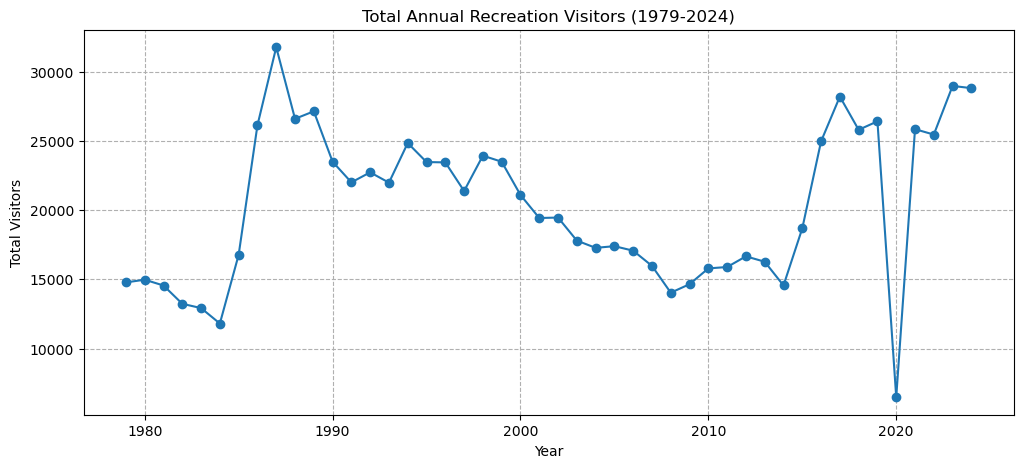

In [79]:
# Visualization of anuual visitation
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Total_Annual'], marker = 'o')

plt.title('Total Annual Recreation Visitors (1979-2024)')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, linestyle = '--')
plt.show()

The graph above shows whether the park is becoming more popular over the decades. Based on the graph, Isle Royale was most popular in 1987 but had a gradual decline until 2014, where it had an increast to almost 30,000 visitors per year in recent years. There was a huge decline that occurred in 2020 when the COVID-19 pandemic first started.

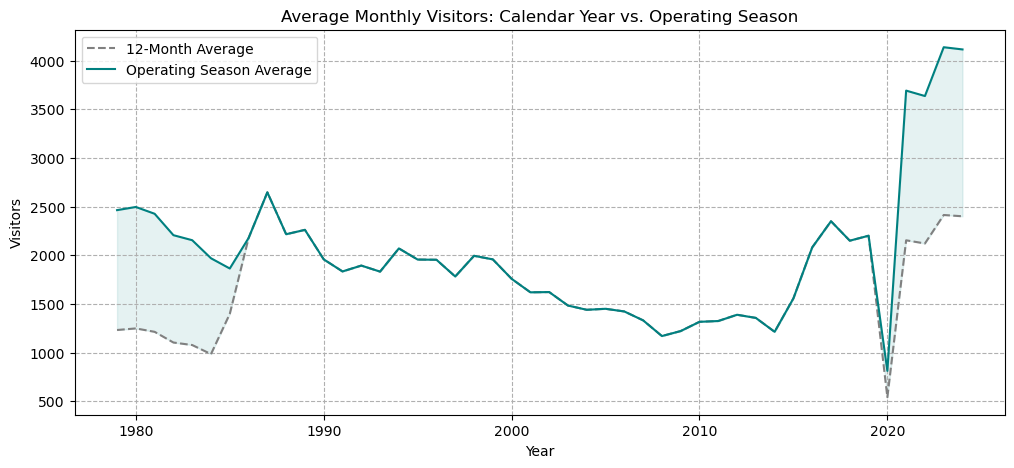

In [84]:
# Visualization of full year average vs. operating average (shows seasonality gap)
plt.figure(figsize = (12, 5))

plt.plot(annual_comparison['Year'], annual_comparison['Full_Avg'], label = '12-Month Average', color = 'gray', linestyle = '--')
plt.plot(annual_comparison['Year'], annual_comparison['Open_Avg'], label = 'Operating Season Average', color = 'teal')
plt.fill_between(annual_comparison['Year'], annual_comparison['Full_Avg'], annual_comparison['Open_Avg'], color = 'teal', alpha = 0.1)

plt.title('Average Monthly Visitors: Calendar Year vs. Operating Season')
plt.xlabel('Year')
plt.ylabel('Visitors')
plt.legend()
plt.grid(True, linestyle = '--')
plt.show()

The graph above explains the intensity of work on Isle Royale. The teal line represents the average number of visitors per month only when the park is open (May-October). The dashed gray line represents the average visitors spread across all 12 months. The shaded seasonality gap is the hidden pressure of the seasonal park. If you only look at the 12-Month Average gray line, you underestimate the park's operational needs by almost 50%. 

### Monthly Visitation Analysis

In [71]:
# Monthly Visitation Analysis (Based on All Years)

# Defining order for plotting
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

# Monthly stats for full year
monthly_stats = df_full.groupby('Month')['Recreation Visitors'].agg([
    'min',
    'max',
    'mean'
]).reindex(month_order)

print('Historical Monthly Extremes:')
print(monthly_stats)

Historical Monthly Extremes:
            min    max         mean
Month                              
January       0     78    29.369565
February      0    116    38.217391
March         0    419    79.000000
April         0    300    93.369565
May           0   1689   792.282609
June        240   6184  3358.956522
July       2160  10702  6527.326087
August     2494  10861  7157.500000
September   640   3421  1892.956522
October      32    474   196.347826
November      0    154    31.086957
December      0   1058   117.717391


#### Monthly Visitation Analysis Per Year

In [82]:
# Monthly visitation analysis per year
yearly_monthly_stats = df_full.groupby([
    'Year', 
    'Month'
])['Recreation Visitors'].sum().reset_index()

# Find the peak month for every year
peaks_by_year = df_full.loc[df_full.groupby('Year')['Recreation Visitors'].idxmax()]

print('Monthly Visitation Peaks per Year:')
print(peaks_by_year[[
    'Year',
    'Month',
    'Recreation Visitors'
]].head(10))

Monthly Visitation Peaks per Year:
     Year   Month  Recreation Visitors
7    1979  August                 5713
19   1980  August                 5934
31   1981  August                 5265
43   1982  August                 5012
55   1983  August                 4953
67   1984  August                 4748
79   1985  August                 6050
91   1986  August                 9583
103  1987  August                10861
115  1988  August                 9471


# Analyzing Big Events Between 1979-2024 (An)

# Regresison (if Time)